# <font color='blue'><div style="text-align: center">Ch 7. Graph</font>

* 그래프는 정점(Vertex)과 간선(Edge)의 집합이다.
* 무방향그래프와 방향 그래프가 있다.
* 그래프의 예로는 통신회선 연결도, 지하철 노선도, 교통지도, 소설네트워크 구성도  등이 있을 수 있다.
* 그래프에서 노드를 탐색하는 것은 그래프에 포함된 모든 노드를 구하거나 사이클이 존재하는 부분을 찾는 것이다.  
* 싸이클은 한 노드에서 출발, 이동하면서 반복되는 노드 없이 출발점으로 돌아오는 것을 말한다. 싸이클이 없는 상황에서 출발한 곳으로 돌아올 수 있는 방법은 갔던 길을 되돌아 오는 방법 밖에 없다.
<center><img src="https://drive.google.com/uc?id=1_peim4ZlhjFdCJUyGTZv6ewaYl07I3LS" width="300" height="200" ></center>
    
* 그래프 자료구조
  * 인접행렬과 인접 리스트로 저장할 수 있다.
<center><img src="https://drive.google.com/uc?id=1RJEly9Y3q-2_zA5sv1J350Klxtuo9xZx" width="300" height="200" ></center>    

    <center><img src="https://drive.google.com/uc?id=1z5083BntshMqrc5UAgfN_SrXHY-JLlh4" width="600" height="200" ></center>
    
* DFS(Depth First Search)
  *  DFS는 출발선에 출발하여 미로를 탐색하듯이 끝까지 가보고 막히면 왔던 곳을 되돌아 오면서 다른 방향을 모색하는 방법이다.
  * DFS 알고리즘은 스택과 visit 리스트를 이용하여 출발노드에서 다음 위치로 이동할 때마다 이동한 곳을 스택과 visit 리스트에 기록하고 막혀서 나올 때는 스택에서 팝하여 되돌아 나온다.
 *  되돌아 나오기 위해 스택을 사용하는 것이다.
 * DFS 과정에서 하나의 노드가 스택에 두번 들어가면 싸이클이 존재하는 것이다.   
  * 스택이 공백이 되면 알고리즘이 끝난다.
  * 스택을 이용한 알고리즘은 재귀로 구현할 수도 있다.(책 참조)
  * 여기서는 스택을 이용해 구현해 볼 것이다.  
  * 알고리즘 <br>
    Step 0: 시작점을 스택에 푸시한다.<br>
    Step 1: 스택에서 노드를 pop 한다.<br>
    Step 2: pop한 노드가 가본 곳이 아니면 노드의 이웃노드 중 방문하지 않은 노드집합을 스택에 푸시하고 팝한 노드를 방문 처리한다.<br>
    Step 3: Step 1에서 Step 2를 스택이 empty될 때까지 반복한다.<br>
    
    <center><img src="https://drive.google.com/uc?id=18yy9GeBzuny3AOnb8cmoyYpy6MqILJEX" width="600" height="300" ></center>
    
    


In [ ]:
class Stack:
    def __init__(self):
        self.s = []

    def push(self, item):
        self.s.append(item)

    def pop(self):
        if self.isEmpty() == False:
            return self.s.pop(-1)
        else:
            return None

    def peek(self):
        if self.isEmpty() == False:
            return self.s[-1]
        else:
            return None

    def isEmpty(self):
        if len(self.s) > 0:
            return False
        else:
            return True

    def size(self):
        return len(self.s)

    def print(self):
        print(self.s)

In [ ]:
class Graph:
    def __init__(self, graph, start):
        self.graph = graph
        self.start = start
        self.s = Stack()
        self.visit = []

    def dfs(self):
        self.s.push(self.start)               # start 노드를 스택에 푸시
        while self.s.isEmpty() == False:      # 스택이 비어있지 않은 동안
            curNode = self.s.pop()            # 스택에서 팝
            if curNode not in self.visit:     # 가본 곳이 아니면 ...
                self.visit.append(curNode)    # 가본 곳으로 등록하고
                for node in sorted(list(set(self.graph[curNode]) - set(self.visit))): #이웃노드 중 방문하지 않은 노드집합을
                    self.s.push(node)         # 스택에 푸시
                print(curNode,end=" ")
                self.s.print()
        return self.visit

g1 = {}
g1['A'] = ['B','C']
g1['B'] = ['A','D','E']
g1['C'] = ['A','E']
g1['D'] = ['B','G']
g1['E'] = ['B','C','G']
g1['F'] = ['G']
g1['G'] = ['D','E','F']

dfs = Graph(g1,'A')
print(dfs.dfs())

A ['B', 'C']
C ['B', 'E']
E ['B', 'B', 'G']
G ['B', 'B', 'D', 'F']
F ['B', 'B', 'D']
D ['B', 'B', 'B']
B ['B', 'B']
['A', 'C', 'E', 'G', 'F', 'D', 'B']


* BFS(Breadth First Search)
  *  BFS는 현재 위치에서 가까운 이웃노드를 다 돌아보고 더 이상 갈 곳이 없으면 방문한 곳에 연결된 노드를 방문하는 방식이다. 직관적으로는 가까운 친구를 먼저 찾아보고 그 다음에는 친구의 친구를 찾는 방식으로 이해할 수 있다.
  * BFS 알고리즘은 큐와 visit 리스트를 이용하여 출발노드에서 가볼 수 있는 곳을 큐에 enQueue 하고 하나씩 deQueue한 다음 방문으로 처리하고 현재 노드에서 가볼 수 있는 곳을 계속 큐에 넣는다.
  * 큐가 empty 가 되면 알고리즘이 끝난다.
  * BFS는 가까운 곳을 먼저 방문하기 때문에 최소경로를 찾을 수 있는 알고리즘이다.
  

In [ ]:
class Queue:
    def __init__(self):
        self.q = []

    def push(self, item):
        self.q.append(item)

    def pop(self):
        if self.isEmpty() == False:
            return self.q.pop(0)

    def size(self):
        return len(self.q)

    def isEmpty(self):
        if len(self.q) > 0:
            return False
        else:
            return True

    def peek(self):
        if self.isEmpty() == False:
            return self.q[0]

    def delete(self, item):
        if item in self.q:
            self.q.remove(item)
        else:
            print("해당 아이템이 존재하지 않습니다.")



In [ ]:
class Graph:
    def __init__(self, graph, start):
        self.graph = graph
        self.start = start
        self.s = Stack()
        self.q = Queue()
        self.visit = []

    def dfs(self):
        self.s.push(self.start)
        while self.s.isEmpty() == False:
            curNode = self.s.pop()
            if curNode not in self.visit:
                self.visit.append(curNode)
                for node in sorted(list(set(self.graph[curNode]) - set(self.visit))):
                    self.s.push(node)
        return self.visit

    def bfs(self):
        visit = [self.start]
        for item in self.graph[self.start]: # 시작노드의 이웃노드를 큐에 추가한다.
            self.q.push(item)

        while self.q.isEmpty() == False:    # 큐가 비어있지 않으면 ...
            item = self.q.pop()
            if not item in visit:  # 현재 아이템이 가본 곳이 아니면 ...
                for _item in self.graph[item]:
                    self.q.push(_item)   # 내 친구 보다는 친구의 친구가 뒤에 push 된다.
                visit.append(item)
        return visit

g1 = {}
g1['A'] = ['B','C']
g1['B'] = ['A','D','E']
g1['C'] = ['A','E']
g1['D'] = ['B','G']
g1['E'] = ['B','C','G']
g1['F'] = ['G']
g1['G'] = ['D','E','F']

bfs = Graph(g1, 'A')
print(bfs.bfs())


['A', 'B', 'C', 'D', 'E', 'G', 'F']


In [ ]:
g1['A']

['B', 'C']

#### 최소비용신장트리
* 간선에 가중치가 존재하는 가중치 그래프에서 가중치의 합이 최소화되도록 구성한 트리를 말한다.
* 최소비용신장트리는 두개의 정점사이에 한개 경로만 존재한다. 그러므로 싸이클도 존재할 수 없다.
* 복잡한 그래프에서 최소비용신장트리를 구성하는 것은 네트워크가 작동할 수 있는 최소 조건을 구하는 의미가 있다.
* 최소비용신장트리를 구하는 방법으로는 Kruskal 알고리즘, Prim 알고리즘, Sollin 알고리즘 등이 있다.

##### Kruskal 알고리즘

* 간선들의 가중값을 정렬한 후, 가장 작은 가중값을 가지는 간선부터 추가해 간다.
* 추가중에 간선의 수가 n-1이 되면 알고리즘이 종료된다. n은 노드 수다.

<center><img src="https://drive.google.com/uc?id=1udy_0nAYtLq8XrPQt1O1uexRGsMwyS1V" width="500" height="500" ></center>

* 위의 그림에서 최소 간선 (4,6) 부터 차례대로 빈 트리에 삽입한다.
* 삽입과정에서 (1,4), (2,4), (3,6)은 싸이클이 형성되므로 스킵한다.
* 삽입하다가 삽입된 간선이 6개(노드수-1)가 되면 알고리즘이 종료된다.
* 싸이클을 탐지하는 방법으로 Union-Find 알고리즘을 사용할 수 있다.


##### Union Find Algorithm
* Union Find 알고리즘은 노드 연결을 나타내는 리스트를 정의하고 추가 되는 엣지(n1, n2)에 대해 Union 해 간다.
* 예를 들어, 현재 [[0,1,2],[3,4]] 이 존재할 때, 아래와 같이 처리한다.
  * [[0,1,2],[3,4]] + [5,6] = [[0,1,2],[3,4],[5,6]] # 연결할 수 없으므로 따로 생성
  * [[0,1,2],[3,4]] + [1,5] = [[0,1,2,5],[3,4]]      # 존재하는 곳에 연결함
  * [[0,1,2],[3,4]] + [1,3] = [[0,1,2,3,4]]        # n1, n2 모두 존재하므로 두개가 존재하는 서브 리스트를 합친다.
  * [[0,1,2],[3,4]] + [0,2] =  싸이클                 # 0과 2가 모두 0번째로 같은 위치에 존재하므로 추가할 필요가 없고 이때 싸이클이 존재한다.
  

In [1]:
def isCycle(u, n): # u: 기존 그래프, n: 연결을 원하는 간선
    idx1 = idx2 = -1
    n1 = n[0]
    n2 = n[1]
    for i in range(len(u)):
        if n1 in u[i]: # 연결을 원하는 간선과 기존 그래프 어디에 매치되는가?
            idx1 = i
        if n2 in u[i]:
            idx2 = i

    if idx1 == -1 and idx2 == -1: # [n1,n2] 이 기존 리스트에 없다면
        u.append([n1,n2])
        print(u)
        return False
    elif idx1 == -1:              # [n1,n2] 이 기존 리스트 중 한 곳에만 있다면
        u[idx2].append(n1)
        print(u)
        return False
    elif idx2 == -1:              # [n1,n2] 이 기존 리스트 중 한 곳에만 있다면
        u[idx1].append(n2)
        print(u)
        return False
    elif idx1 != idx2:            # [n1,n2] 이 기존 리스트에 서로 다른 곳에 존재한다면
        d1 = u[idx1]
        d2 = u[idx2]
        union = d1 + d2
        u.remove(d1)
        u.remove(d2)
        u.append(union)
        print(u)
        return False

    elif idx1 == idx2 and len(u[idx1]) > 2:# [n1,n2] 이 기존 리스트에 같은 곳에 존재한다면
        print(u)
        return True

u = [[0, 1, 2],[3, 4]]
print(isCycle(u, (2,3)))
u = [[0, 1, 2],[3, 4]]
print(isCycle(u, (0,2)))
u = [[0, 1, 2],[3, 4]]
print(isCycle(u, (1,5)))
u = [[0, 1, 2],[3, 4]]
print(isCycle(u, (4,6)))


[[0, 1, 2, 3, 4]]
False
[[0, 1, 2], [3, 4]]
True
[[0, 1, 2, 5], [3, 4]]
False
[[0, 1, 2], [3, 4, 6]]
False


In [ ]:
class SpanningTree:
    def __init__(self, graph):
        self.graph = graph
        self.nodes = set()
        self.union = [] # union-find 알고리즘에서 기존 엣지 리스트

        # 그래프의 노드를 구함
        for edge in graph:
            self.nodes.add(edge[0])
            self.nodes.add(edge[1])
        self.nNode = len(self.nodes)

    def isCycle(self, n1, n2):
        idx1 = idx2 = -1
        for i in range(len(self.union)):
            if n1 in self.union[i]:
                idx1 = i
            if n2 in self.union[i]:
                idx2 = i

        if idx1 == -1 and idx2 == -1:
            self.union.append([n1, n2])
            return False
        elif idx1 == -1:
            self.union[idx2].append(n1)
            return False
        elif idx2 == -1:
            self.union[idx1].append(n2)
            return False
        elif idx1 != idx2:
            d1 = self.union[idx1]
            d2 = self.union[idx2]
            union = d1 + d2
            self.union.remove(d1)
            self.union.remove(d2)
            self.union.append(union)
            return False
        elif idx1 == idx2 and len(self.union[idx1]) > 2:
            print(self.union[idx1])
            return True
        else:
            return False

    def kruskal(self):
        self.graph.sort(key = lambda t: t[2]) # 그래프를 2번째 원소기준으로 소트한다.
        tree = []  # 최소비용신장트리를 담을 리스트를 만든다.
        nedges = 0 # nedges == self.nNode - 1이면 알고리즘이 끝난다.
        i = 0
        while nedges < self.nNode - 1:
            if self.isCycle(self.graph[i][0],self.graph[i][1]) == False:
                tree.append(self.graph[i])
                nedges += 1
            else:
                print("싸이클 발견",self.graph[i] )
            i += 1

        return tree

g = [(0,1,9),(0,2,10),(1,3,10),(1,4,5),(1,6,3),(2,3,9),(2,4,7),(2,5,2),(3,5,4),(3,6,8),(4,6,1),(5,6,6)]
t = SpanningTree(g)
print(t.kruskal())

[4, 6, 1]
싸이클 발견 (1, 4, 5)
[2, 5, 3, 4, 6, 1]
싸이클 발견 (2, 4, 7)
[2, 5, 3, 4, 6, 1]
싸이클 발견 (3, 6, 8)
[(4, 6, 1), (2, 5, 2), (1, 6, 3), (3, 5, 4), (5, 6, 6), (0, 1, 9)]


### Dijkstra 알고리즘

* BFS를 사용하여 최소거리 경로를 찾을 수 있다.    
* 다익스트라 알고리즘은 최소 Cost를 가지는 경로를 찾을 수 있는 알고리즘이다.
* 여기서, Cost는 시간일 수도 있고, 시간, 신호등 수, 주변 경관 등을 적절하게 점수화 한 것일 수도 있다.     
   예를 들어, 시간이 오래 걸리거나 신호등이 많거나 차선이 좁으면 상승하는  Cost  함수를 만들 수 있다면 이 Cost 함수를 최소화 하는 경로를 찾을 수 있다는 의미이다.
* 이를 이용하면 네비게이션 알고리즘에서 최단경로, 최소시간, 최소비용, 최적 경로라는 이름으로 경로를 탐색하고 사용자는 이 중 적절한 경로를 선택하도록 하는 것이 가능하다.
* 다익스트라 알고리즘은 현재노드를 통해 연결된 노드로 가는 것과 다른 경로를 통해 가는 Cost를 비교하여 더 작은 Cost가 있을 경우, 업데이트하는 방법이다.
* 아래의 그림에서 A로 가는 방법은 start에서 A로 가는 방법과 start -> B -> A의 방법이 있고 이 중 후자가 더 빠르다.
* 컴퓨터는 현재 위치에서 바로 다음의 최적 위치는 찾을 수 있지만, 그 다음을 고려한 의사결정은 할 수 없다. 이러한 문제로 다익스트라 알고리즘이 최적해를 주지 못한다.

<center><img src="https://drive.google.com/uc?id=17-N_4cqBA_H9BKKVgTeZDuhCgwVKSH8s" width="300" height="150" ></center>


* 위 그래프를 리스트에 저장해보자.

In [ ]:
# 경로 그래프를 만든다.
graph = (['start','A', 6],['start','B', 2], ['A', 'finish', 1], ['B', 'finish', 5], ['B', 'A', 3])
graph

(['start', 'A', 6],
 ['start', 'B', 2],
 ['A', 'finish', 1],
 ['B', 'finish', 5],
 ['B', 'A', 3])

In [ ]:
'''
노드 집합을 만든다.
노드 집합에서 노드를 꺼내 방문하기 시작한다. 방문한 노드는 visits로 옮긴다.
nodes에 있는 모든 노드가 visits로 이동하면 알고리즘이 끝난다.
'''
nodes = set()
for node in graph:
    nodes.add(node[0])
    nodes.add(node[1])
nodes


{'A', 'B', 'finish', 'start'}

In [ ]:
aaa = float("inf")
type(aaa), aaa

(float, inf)

In [ ]:
# 방문한 노드를 기록하기 위한 집합을 만든다.
visits = set()

# 각 노드는 출발점과의 거리와 최적경로를 만족하는 부모노드를 지정해야 한다.
# 처음에는 최적경로를 모르므로 모든 노드와 거리는 무한대로 설정하고 각 노드의 부모노드는 "모름"으로 설정한다.

cost = {}

for node in nodes:
    cost[node] = [float("inf"), None]  # [노드까지 가는 비용, 부모노드]

# 시작과 끝 노드를 정의한다.
start = 'start'
end = 'end'

# 시작노드의 거리는 0으로 설정한다.
curNode = start
cost[curNode][0] = 0

print(cost)

{'A': [inf, None], 'start': [0, None], 'B': [inf, None], 'finish': [inf, None]}


In [ ]:
# curNode에서 갈 수 있는 노드를 반환하는 함수다.
# 'start'에서 갈 수 있는 노드는 'A', 'B' 다.

def _neighbor(curNode):
    # curNode에 연결된 이웃노드를 리스트로 리턴한다.
    neighbor = {}
    for node in graph:
        if node[0] == curNode:
            neighbor[node[1]] = node[2]
        elif node[1] == curNode:
            neighbor[node[0]] = node[2]
    return neighbor

neighbors = _neighbor(curNode)
neighbors

{'A': 6, 'B': 2}

In [ ]:
# 그래프에서 노드 n1, n2의 가중값을 리턴한다.
def _getWeight(n1, n2):
    for node in graph:
        if (node[0] == n1 and node[1] == n2) or (node[0] == n2 and node[1] == n1):
            return node[2]
    return None

# curNode를 방문처리한다.
visits.add(curNode)
nodes.remove(curNode)   # 안 가본 노드


In [ ]:
curNode, cost

('start',
 {'A': [inf, None],
  'start': [0, None],
  'B': [inf, None],
  'finish': [inf, None]})

In [ ]:
# 모든 이웃에 대해 현재 노드를 통해 이웃노드에 접근하는 cost가 더 작을 경우, cost 값을 갱신하고 부모노드를 변경한다.
# 'A': [6, 'start'] 는 'A'에 'start'를 통해 접근할 경우, cost가 6이란 의미다.
# 만약, 'A'에 다른 노드를 통해 접근할 때 더 작은 cost가 있다면 갱신한다.
# curNode에서 갈 수 있는 모든 이웃에 대해
# curNode를 통해 node로 가는 비용은 curNode까지 오는 비용 + curNode에서 node 까지 가는 비용이므로
# cost[curNode][0] + _getWeight(curNode,node)가 된다.
# 이 비용이 현재시점에서 알고있는 node 비용보다 작다면 node의 비용과 parent 노드를 curNode를 통해 가는 것으로 갱신한다.
# 초기 cost는 {'start': [0, None], 'B': [inf, None], 'A': [inf, None], 'finish': [inf, None]} 이다.
# 현재 노드의 이웃노드를 하나씩 꺼낸다.

# curNode : start
for node in neighbors:
    if cost[curNode][0] + _getWeight(curNode,node) < cost[node][0]:
        print(curNode)
        cost[node][0] = cost[curNode][0] + _getWeight(curNode, node)
        cost[node][1] = curNode

print(curNode, nodes)
print(cost)

start
start
start {'A', 'B', 'finish'}
{'A': [6, 'start'], 'start': [0, None], 'B': [2, 'start'], 'finish': [inf, None]}


* 다시 nodes 집합 {'finish', 'B', 'A'} 중에 최소 비용을 가지는 노드를 curNode로 선정하고 위 과정을 반복한다.
   여기서는 B가 선택된다.
* 이를 위해서는 cost에서 nodes에 있는 키를 대상으로 최소비용노드를 선택해야 한다.
* 딕셔너리 부분집합을 정의하기 위해 아래의 코드를 사용할 수 있다.<br>


In [ ]:
# 딕셔너리 필터는 nodes에서 cost가 최소인 노드를 찾아 리턴한다.
# cost 중에 현재 노드에서 이동가능한 노드만 cost가 갱신 되어 있으므로 최소노드는 이동 가능한 노드 중에만 선택된다.
def dicFilter(cost, nodes):
    import sys
    mini = sys.maxsize       # 컴퓨터가 기억할 수 있는 최대값
    for key, value in cost.items():
        if key in nodes:
            if value[0] < mini:
                mini = value[0]
                curNode = key
    return curNode

print(cost, nodes)
curNode = dicFilter(cost, nodes)
curNode


{'A': [6, 'start'], 'start': [0, None], 'B': [2, 'start'], 'finish': [inf, None]} {'A', 'B', 'finish'}


'B'

In [ ]:
# 'B'에서 갈 수 있는 노드는 'A', 'finish' 다.
print(curNode)
visits.add(curNode)
nodes.remove(curNode)
neighbors = _neighbor(curNode)
print(neighbors)

B
{'start': 2, 'finish': 5, 'A': 3}


In [ ]:
# 모든 이웃에 대해 현재 노드를 통해 이웃노드에 접근하는 cost가 더 작을 경우, dist 값을 갱신하고 부모노드를 변경한다.
# 'A' 로 갈 수 있는 방법이 'start'에서 직접 가는 것 보다 'B'를 통과해 가는 것이 비용이 작아 'A'의 비용과 부모노드가 갱신되었다.

for node in neighbors:
    if cost[curNode][0] + _getWeight(curNode,node) < cost[node][0]:
        cost[node][0] = cost[curNode][0] + _getWeight(curNode, node)
        cost[node][1] = curNode
print(curNode, nodes)
print(cost)

B {'A', 'finish'}
{'A': [5, 'B'], 'start': [0, None], 'B': [2, 'start'], 'finish': [7, 'B']}


In [ ]:
# {'finish', 'A'} 중에 비용이 작은 노드는 'A'다.
curNode = dicFilter(cost, nodes)
print(curNode)

A


In [ ]:
neighbors = _neighbor(curNode)
print(neighbors)

visits.add(curNode)
nodes.remove(curNode)

for node in neighbors:
    if cost[curNode][0] + _getWeight(curNode,node) < cost[node][0]:
        cost[node][0] = cost[curNode][0] + _getWeight(curNode, node)
        cost[node][1] = curNode
print(curNode, nodes)
print(cost)

{'start': 6, 'finish': 1, 'B': 3}
A {'finish'}
{'A': [5, 'B'], 'start': [0, None], 'B': [2, 'start'], 'finish': [6, 'A']}


In [ ]:
nodes

{'finish'}

* 이제 노드에는 finish 하나만 남았고 finish의 이웃이 없으므로 알고리즘은 종료된다.
* 실제로는 node가 완전히 비워질 때까지 알고리즘을 반복해야 한다.
* cost에서 최소비용 경로는 아래와 같이 구할 수 있다.
   finish <- finish의 부모인 'A' <- 'A'의 부모인 'B' <- 'B'의 부모인 'start' 순서다.
* 최종적으로 start -> 'B' -> 'A' -> 'finish' 가 최소비용경로다.   

### 예제:아래의 그래프에서 0->3으로 가는 최소비용경로는?

<center><img src="https://drive.google.com/uc?id=1ld8EGLdOA37raFZwAx5xzeLtuSLqmhDv" width="400" height="300" ></center>

In [ ]:
# 그래프를 정의한다.(이 그래프는 양방향이다.)

graph = [(0, 1, 7), (0, 4, 3), (0, 5, 10), (1, 2, 4), (1, 4, 2),
         (1, 5, 6), (1, 3, 10), (2, 3, 2),(3, 5, 9), (3, 6, 4), (4, 6, 5)]

nodes = set()
for node in graph:
    nodes.add(node[0])
    nodes.add(node[1])
nodes


{0, 1, 2, 3, 4, 5, 6}

In [ ]:
# 방문한 노드를 기록하기 위한 집합을 만든다.
visits = set()

# 출발점에서 모든 노드와 거리는 무한대로 설정하고 각 노드의 부모노드는 "모름"으로 초기설정한다.

cost = {}

for node in nodes:
    cost[node] = [float("inf"),None]

# 시작과 끝 노드를 정의한다.
start = 0
end = 3

# 시작노드의 거리는 0으로 설정한다.
curNode = start
cost[curNode][0] = 0

print(cost)

{0: [0, None], 1: [inf, None], 2: [inf, None], 3: [inf, None], 4: [inf, None], 5: [inf, None], 6: [inf, None]}


이제 다익스트라 알고리즘을 시작할 준비가 끝났다.

* Step 0: 시작점을 현재 노드로 설정한다.
* Step 1: 현재 노드를 방문한것으로 처리한다.
* Step 2: 현재노드의 모든 이웃노드를 구하고 현재노드를 통해 이웃노드로 가는 비용과 이 노드를 거치지 않고 가는 비용을 비교하여 만약, 현재노드를 통해 가는 것이 작으면 비용과 부모노드를 업데이트 한다.
* Step 3: 방문하지 않은 노드들 중에 최소비용노드를 찾아 현재노드로 지정하고 Step 1으로 이동한다.

In [ ]:
def _neighbor(curNode):
    # curNode에 연결된 이웃노드를 리스트로 리턴한다.
    neighbor = {}
    for node in graph:
        if node[0] == curNode:
            neighbor[node[1]]= node[2]
        elif node[1] == curNode:
            neighbor[node[0]] = node[2]
    return neighbor

def _getWeight(n1, n2):
    # 그래프에서 노드 n1, n2의 가중값을 리턴한다.
    for node in graph:
        if node[0] == n1 and node[1] == n2:
            return node[2]
        elif node[0] == n2 and node[1] == n1:
            return node[2]
    return None

def _dicFilter(cost, nodes):
    # 이동할 수 있는 노드 중에 cost기 최소인 노드를 리턴한다. --> 탐욕 알고리즘
    # cost 중에 현재 노드에서 이동 가능한 노드만 cost가 갱신 되어 있으므로 최소노드는 이동 가능한 노드 중에만 선택된다.
    import sys
    mini = sys.maxsize
    for key, value in cost.items():
        if key in nodes: # 아직 방문하지 않은 노드만
            if value[0] < mini:
                mini = value[0]
                curNode = key
    return curNode

while True:
    visits.add(curNode)       # 현재 노드를 방문 처리한다.
    nodes.remove(curNode)     # 남은 노드집합에서 현재 노드를 삭제한다.
    neighbors = _neighbor(curNode) # 현재 노드에서 갈 수 있는 이웃노드 집합을 구한다.

    # 모든 이웃에 대해 현재 노드를 통해 이웃노드에 접근하는 cost가 더 작을 경우, cost 값을 갱신하고 부모노드를 변경한다.
    for node in neighbors:
        if cost[curNode][0] + _getWeight(curNode,node) < cost[node][0]:
            cost[node][0] = cost[curNode][0] + _getWeight(curNode, node)
            cost[node][1] = curNode

    if len(nodes) > 0:
        print(curNode)
        curNode = _dicFilter(cost, nodes) # 이웃노드 중 가장 빠르게 갈 수 있는 노드를 구해 현재 노드를 갱신한다.(Greedy Algorithm)
        print(curNode)
    else:
        break

path = [end]

while end != start:
    path.append(cost[end][1])
    end = cost[end][1]

print(path[::-1])

0
4
4
1
1
6
6
2
2
5
5
3
[0, 4, 1, 2, 3]


<font color='red'>H.W #11 :  다익스트라 알고리즘으로 지하철 최단 경로를 구하시오. <br>
(1) 먼저, 위 코드를 클래스로 만들어 재사용 가능하도록 개발하시오. <br>
      (class dijkstra 이름으로 개발하고 setEdge(self,a,b,w), getPath(self,start,end) 메소드를 구현하세요) <br>
(2) subway.csv 파일에서 원하는 경로에 대한 최소비용 경로를 계산해보세요. <br></font>

### 네트워크 중심성

* 페이스북 같이 사람들의 네트워크를 그래프로 표현할 수 있다.

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

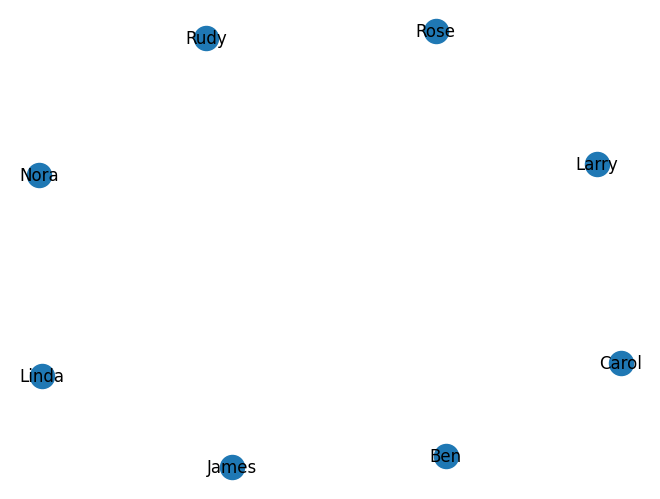

In [ ]:
G = nx.Graph()
nodes = ['Ben','Carol','Rose','Nora','Larry','Rudy','James','Linda']
G.add_nodes_from(nodes)
nx.draw(G, with_labels = True)

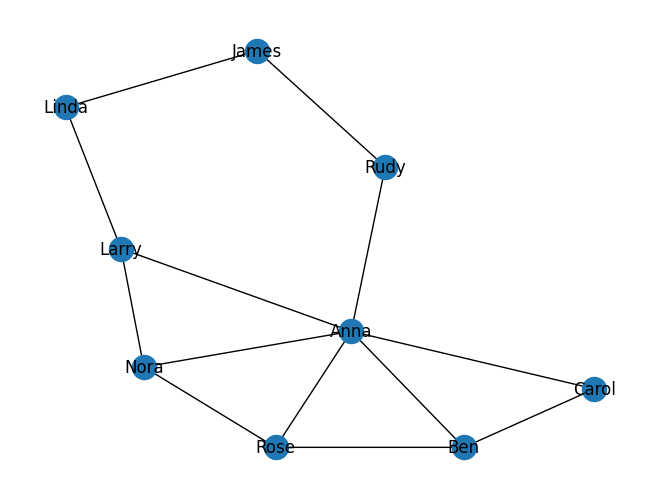

In [ ]:
G.add_edge('Anna','Carol')
G.add_edge('Anna','Ben')
G.add_edge('Anna','Rose')
G.add_edge('Anna','Nora')
G.add_edge('Anna','Larry')
G.add_edge('Anna','Rudy')
G.add_edge('Larry','Linda')
G.add_edge('Larry','Nora')
G.add_edge('Linda','James')
G.add_edge('James','Rudy')
G.add_edge('Nora','Rose')
G.add_edge('Rose','Ben')
G.add_edge('Ben','Carol')
nx.draw(G, with_labels = True)

In [ ]:
# 연결중심성: 노드별로 몇개와 연결되어 있는가를 측정하여 많이 연결되어 있는 노드가 중심노드로 볼 수 있다.
degree_dict = dict(G.degree(G.nodes()))
degree_dict

{'Ben': 3,
 'Carol': 2,
 'Rose': 3,
 'Nora': 3,
 'Larry': 3,
 'Rudy': 2,
 'James': 2,
 'Linda': 2,
 'Anna': 6}

In [ ]:
# 근접 중심성: 한 노드에서 다른 노드로 가는 경로가 짧을수록 중요한 노드라는 개념이다.
# 계산과정은 노드 A에서 다른 노드로 가는 경우의 수는 n-1개가 있고 n-1개 최단 경로(너비탐색) 길이의 평균을 구한 다음 이에 대한 역수를 구한 값이다.
# 여기서는 Anna를 통하면 다른 사람에게 접근이 용이함을 알 수 있다.

closeness_dict = nx.closeness_centrality(G)
closeness_dict

{'Ben': 0.5333333333333333,
 'Carol': 0.5,
 'Rose': 0.5333333333333333,
 'Nora': 0.5714285714285714,
 'Larry': 0.6153846153846154,
 'Rudy': 0.5714285714285714,
 'James': 0.4444444444444444,
 'Linda': 0.47058823529411764,
 'Anna': 0.8}

In [ ]:
# 고유벡터 중심성: 각 노드의 근접행렬의 분산에서 노드 A가 차지하는 비율을 구해 그 비율이 크다면 네트워크에서 중요한 노드라는 의미다.
eigenvector_dict = nx.eigenvector_centrality(G)
eigenvector_dict

{'Ben': 0.3675125293405861,
 'Carol': 0.27825878129984094,
 'Rose': 0.39059373706466227,
 'Nora': 0.37926639951945385,
 'Larry': 0.3179402349249892,
 'Rudy': 0.19745028144306706,
 'James': 0.09468281347772224,
 'Linda': 0.12221576742869383,
 'Anna': 0.5719492867084267}

<font color='red'>H.W #12 : 지하철 노선에서 네트워크 중심 위치를 구하시오.</br>
(1) 근접중심성, 연결중심성, 고유벡터 중심성에 의해 중심 역을 구하고 해석하시오. </font>